# How Primitives Work

Mechanics of the drawing primitives in `mplchart.primitives` — the display components that control *how* things are rendered. They fall into a few roles: price/volume renderers (`Candlesticks`, `OHLC`, `Volume`), indicator renderers (`LinePlot`, `AreaPlot`, `BarPlot`), condition primitives (`Stripes`, `Markers`), chart furniture (`Pane`, `HLine`, `VLine`), and pattern primitives (`Swings`, `ZigZag`, `TrendLines`).

Primitives are backend-agnostic: everything on this page works identically with pandas or polars data (this page uses pandas). This page focuses on mechanics; for a visual catalog of charts see the Gallery page.

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import (
    Candlesticks, OHLC, Volume,
    LinePlot, AreaPlot, BarPlot,
    Stripes, Markers,
    Pane, HLine, VLine,
    Swings, ZigZag, TrendLines,
)
from mplchart.indicators import SMA, ROC, RSI, MACD, ADX

prices = sample_prices()

## Price and volume

`Candlesticks` and `OHLC` render the OHLC columns — both support `colorup`, `colordn` and `alpha`. `Volume` draws volume bars on a twin scale of the current pane, with an optional moving-average overlay via `sma=`.

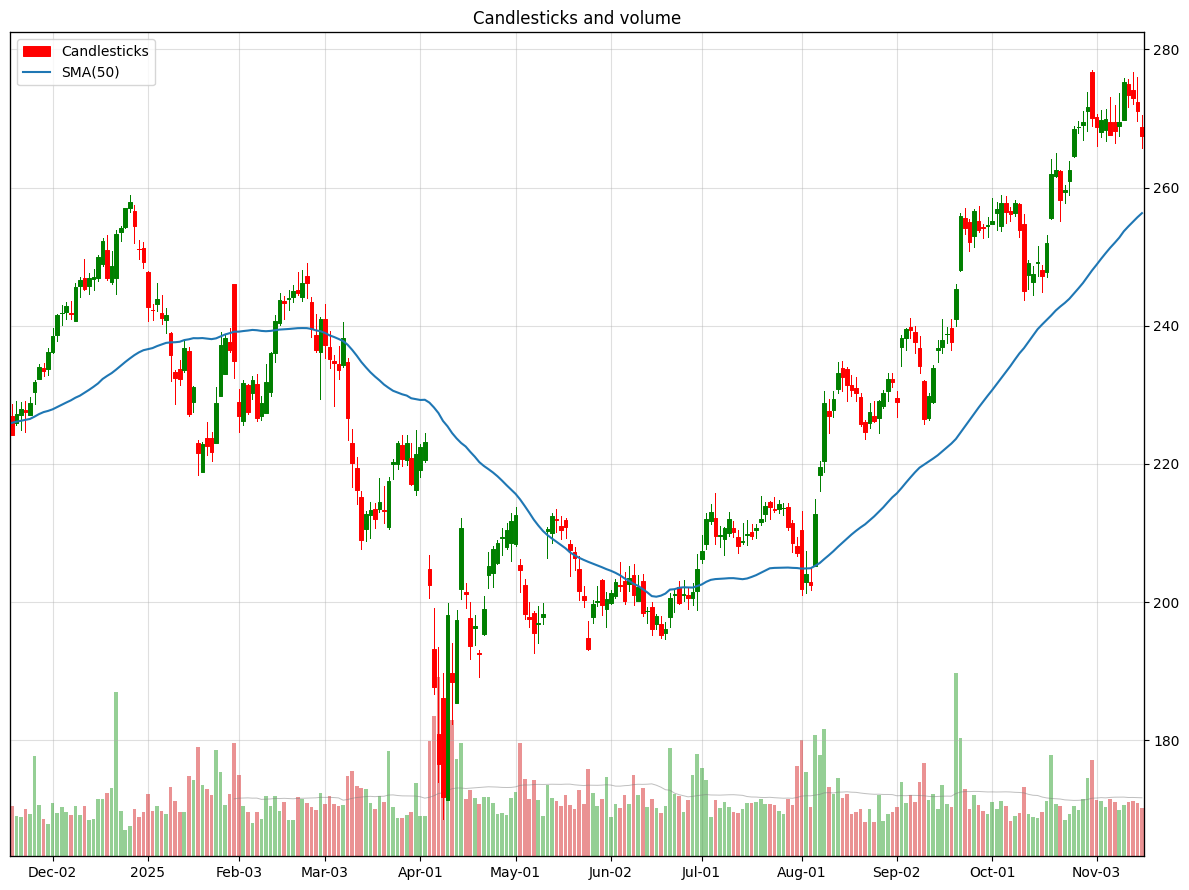

In [2]:
Chart(prices, title="Candlesticks and volume", max_bars=250).plot(
    Candlesticks(colorup="green", colordn="red"),
    Volume(sma=50),
    SMA(50),
).show()

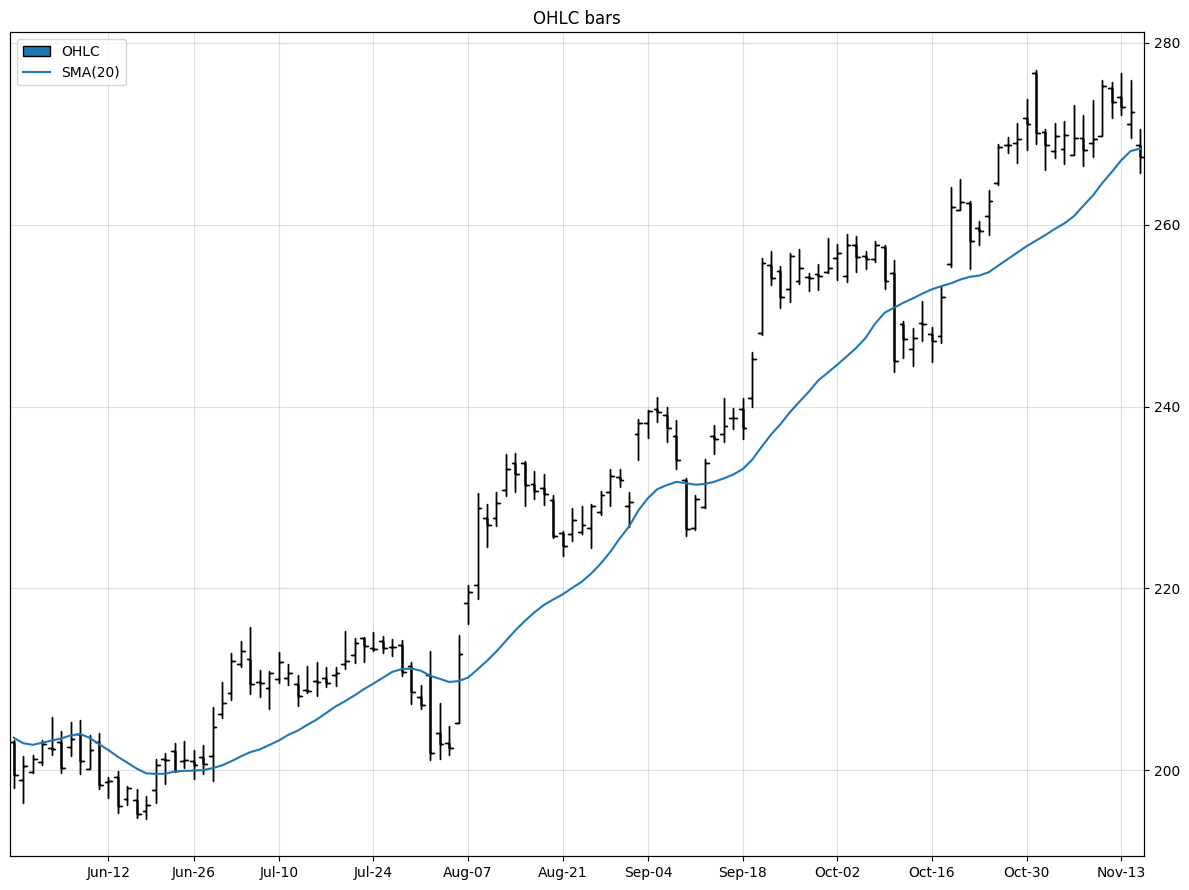

In [3]:
Chart(prices, title="OHLC bars", max_bars=120).plot(
    OHLC(),
    SMA(20),
).show()

## Indicator renderers

Indicators plot with an automatic line plot by default. Wrap them in a renderer to control the look: `LinePlot` supports `style` (`solid`, `dashed`, `marker`), `color`, `width`, `alpha`; `AreaPlot` fills, `BarPlot` draws bars. Renderers accept an indicator, an expression, or a plain column name like `"close"`.

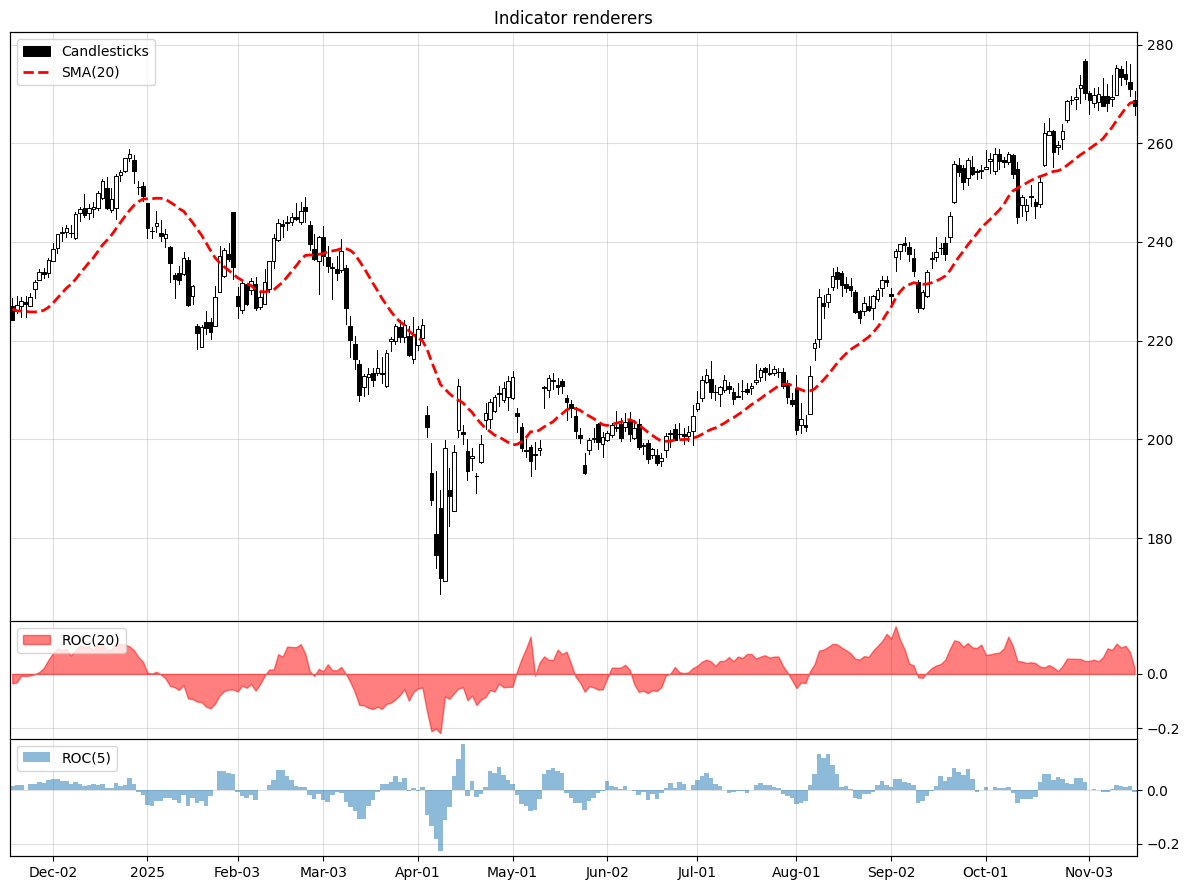

In [4]:
Chart(prices, title="Indicator renderers", max_bars=250).plot(
    Candlesticks(),
    LinePlot(SMA(20), style="dashed", color="red", width=2),
).pane("below").plot(
    AreaPlot(ROC(20), color="red", alpha=0.5),
).pane("below").plot(
    BarPlot(ROC(5), alpha=0.5),
).show()

## Condition primitives

`Stripes` shades the background where a condition holds; `Markers` marks the bars where the condition changes value. The condition is a boolean series expression — built with `as_expr()` on the pandas side (native comparisons on the polars side; see the expressions page). `Markers` accepts a color pair for off/on transitions.

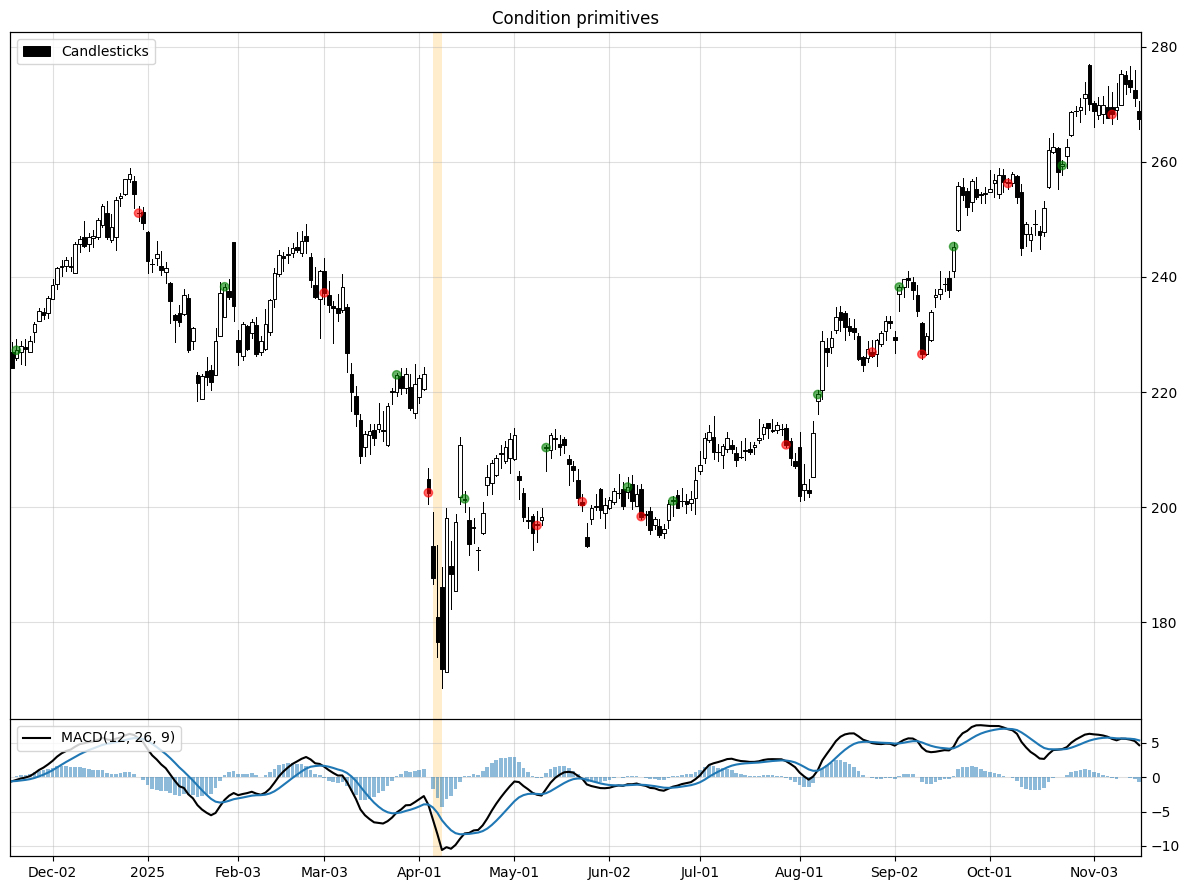

In [5]:
Chart(prices, title="Condition primitives", max_bars=250).plot(
    Candlesticks(),
    Stripes(RSI(14).as_expr() < 30, color="orange", alpha=0.2),
).pane("below").plot(
    MACD(),
    Markers(MACD().as_expr("macdhist") > 0, color=["red", "green"]),
).show()

## Panes and reference lines

The `Pane` primitive is the inline equivalent of the `pane()` method — usable inside a flat `plot()` call, with the same `target` (`"below"`, `"above"`, ...), `height_ratio` and `yticks` options. `HLine` draws a horizontal reference line on the current pane; `VLine` a vertical line across all panes at a given date. Both are also available as fluent methods: `chart.hline(...)`, `chart.vline(...)`.

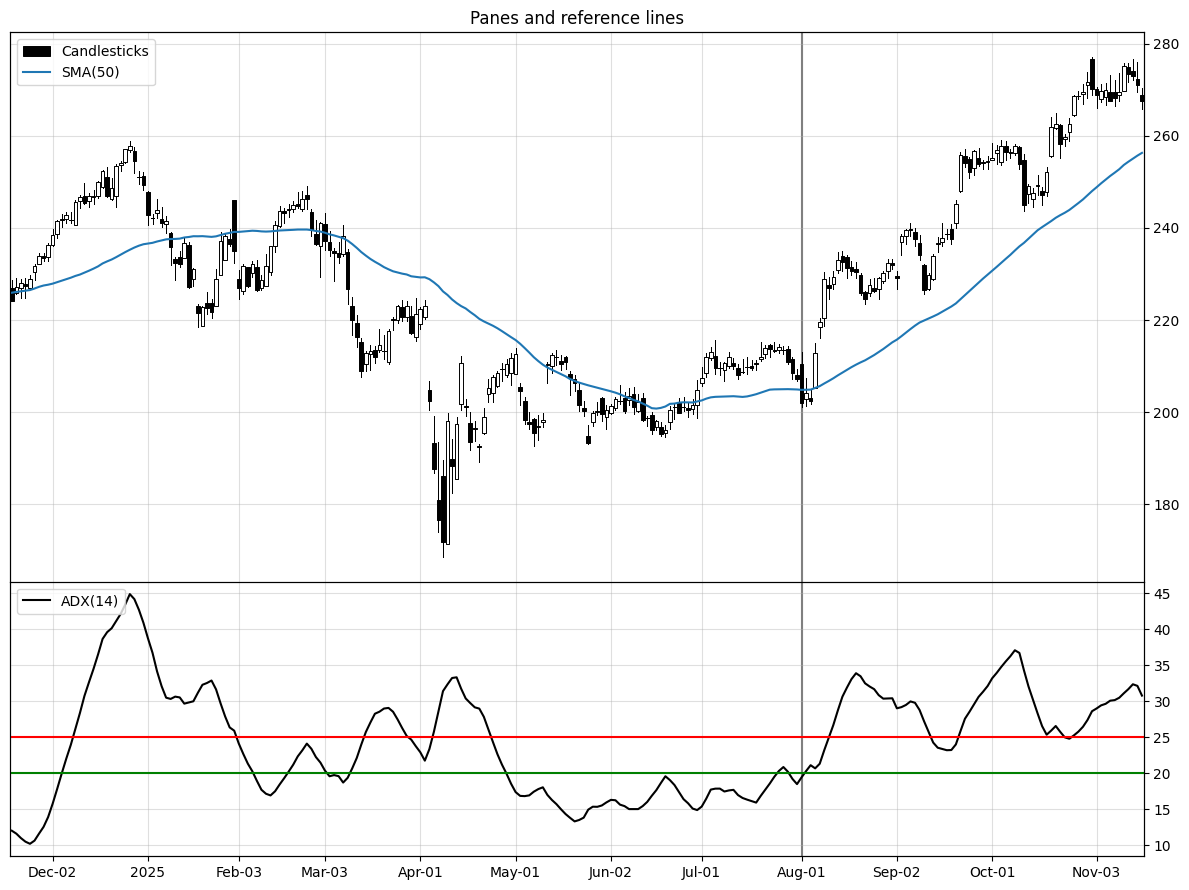

In [6]:
Chart(prices, title="Panes and reference lines", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    VLine("2025-08-01", color="gray"),
    Pane("below", height_ratio=0.5),
    ADX(),
    HLine(20, color="green"),
    HLine(25, color="red"),
).show()

## Pattern primitives

`Swings` marks local highs and lows (controlled by `span`); `ZigZag` connects significant swings, filtering out minor moves.

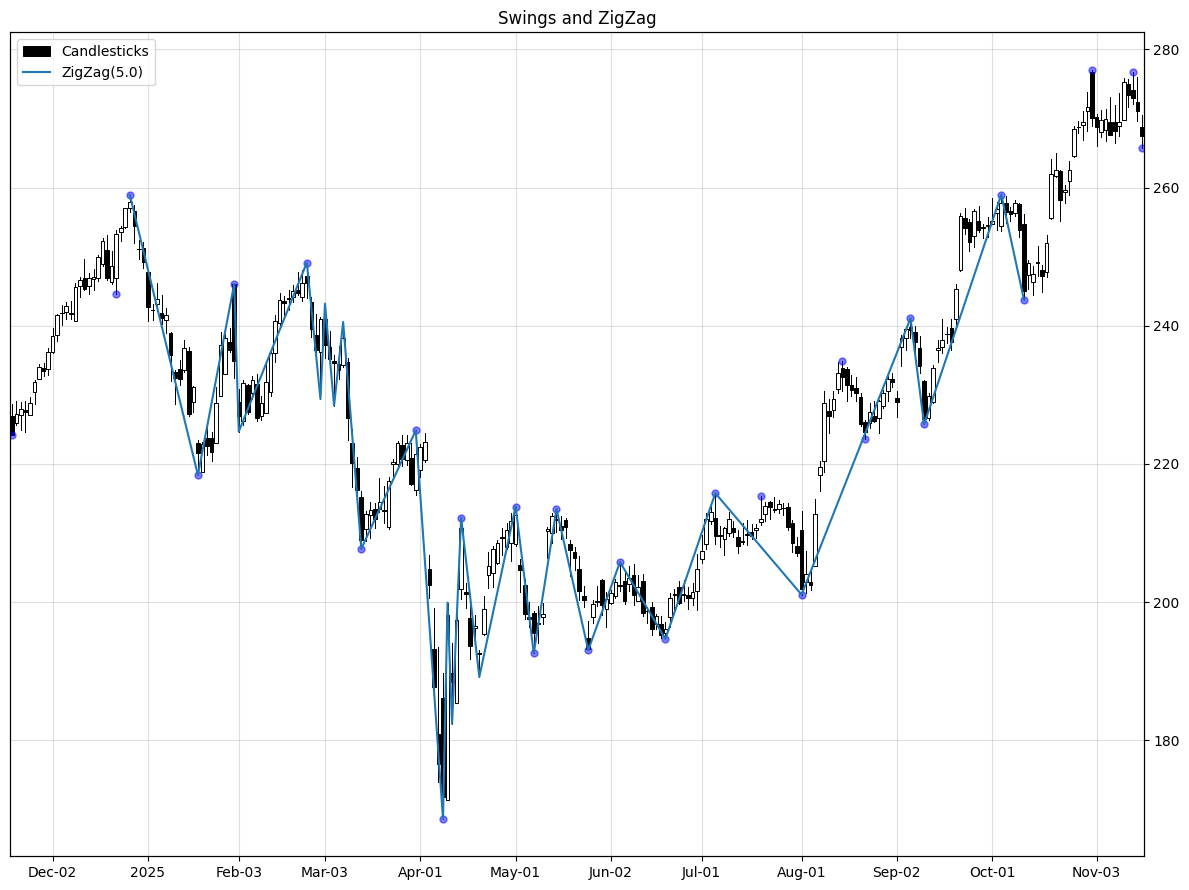

In [7]:
Chart(prices, title="Swings and ZigZag", max_bars=250).plot(
    Candlesticks(),
    Swings(span=5, color="blue"),
    ZigZag(),
).show()

`TrendLines` is an experimental walkback trend-line detector: it fits support and resistance ladders anchored at recent swings — candidate legs drawn faded, the winning leg highlighted with its touch points. The API is likely to change.

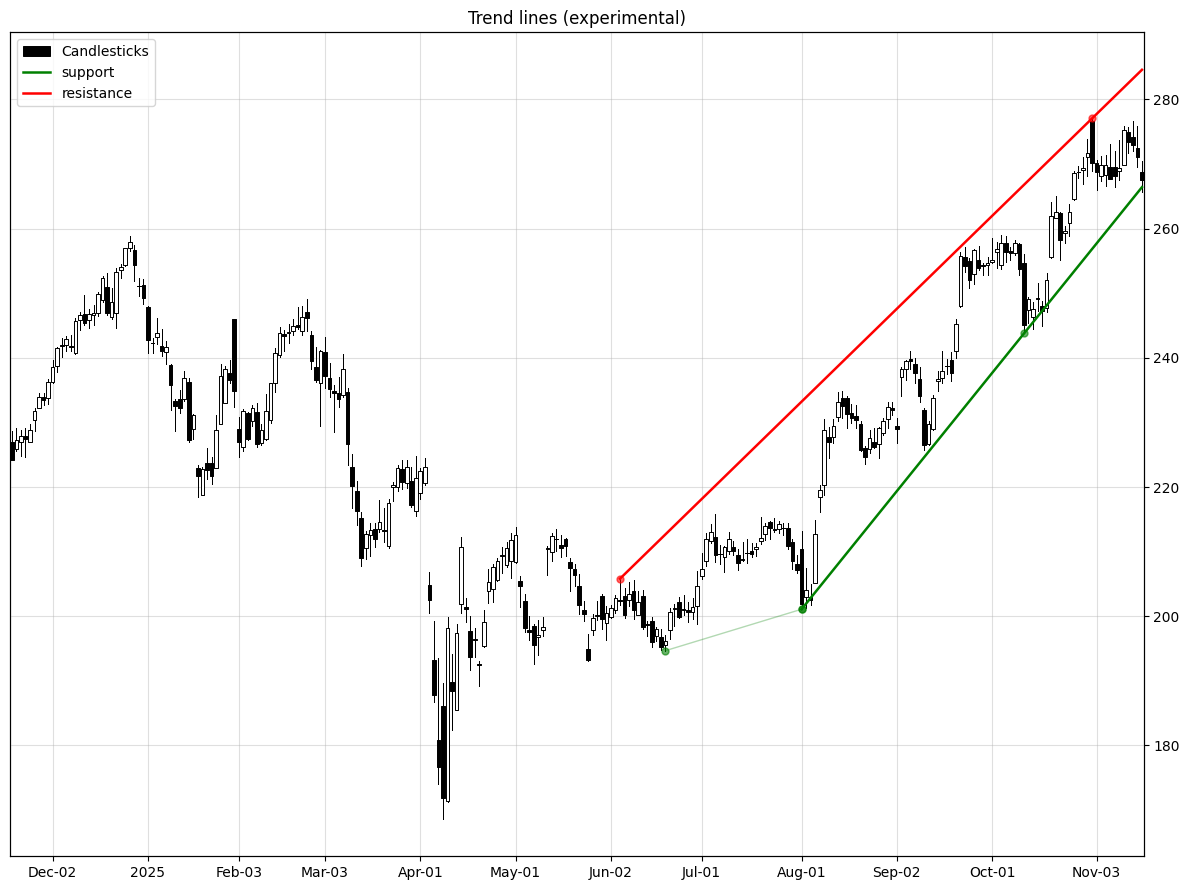

In [8]:
Chart(prices, title="Trend lines (experimental)", max_bars=250).plot(
    Candlesticks(),
    TrendLines(span=5),
).show()